# CVAE - Ghosh2022 - Parte Tomate

# Etapa 3

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

DB_PATH = "../db/tfm_vocs.db"
PARQUET_PATH = "../db/data/processed/abundancias_ghosh2022.csv"
DATASET_ORIGIN = "Ghosh2022"

In [2]:
import pickle
import numpy as np
from pathlib import Path

MODELS_DIR = Path("../models")

def export_cvae(dataset_slug, encoder, decoder, scaler, compound_ids,
                 iso_forest=None, autoencoder=None,
                 scores_loo=None, errores_loo_ae=None, meta=None):
    out = MODELS_DIR / dataset_slug
    out.mkdir(parents=True, exist_ok=True)
    encoder.save(out / "cvae_encoder.keras")
    decoder.save(out / "cvae_decoder.keras")

    with open(out / "scaler.pkl", "wb") as f:
        pickle.dump(scaler, f)
    with open(out / "compound_ids.pkl", "wb") as f:
        pickle.dump(list(compound_ids), f)

    if autoencoder is not None:
        autoencoder.save(out / "autoencoder.keras")
    if iso_forest is not None:
        with open(out / "isolation_forest.pkl", "wb") as f:
            pickle.dump(iso_forest, f)
    if scores_loo is not None:
        np.save(out / "scores_loo.npy", scores_loo)
    if errores_loo_ae is not None:
        np.save(out / "errores_loo_ae.npy", errores_loo_ae)
    if meta:
        with open(out / "cvae_meta.pkl", "wb") as f:
            pickle.dump(meta, f)

    print(f"Exportado: {dataset_slug} -> {out}")

In [3]:
SEED = 42
tf.keras.utils.set_random_seed(SEED)

### Carga de datos

In [4]:
SPECIES = "Solanum lycopersicum"

con = sqlite3.connect(DB_PATH)

muestras = pd.read_sql(
    f"SELECT * FROM muestras WHERE dataset_origin = '{DATASET_ORIGIN}' AND species = '{SPECIES}'", con
)
compuestos_all = pd.read_sql(
    f"SELECT * FROM compuestos WHERE dataset_origin = '{DATASET_ORIGIN}'", con
)
abundancias_all = pd.read_csv(PARQUET_PATH)

con.close()

abundancias = abundancias_all[abundancias_all["sample_id"].isin(muestras["sample_id"])]
compuesto_ids_especie = abundancias["compuesto_id"].unique()
compuestos = compuestos_all[compuestos_all["compuesto_id"].isin(compuesto_ids_especie)]

print("Muestras:", muestras.shape)
print("Compuestos (tomate):", compuestos.shape)
print("Abundancias:", abundancias.shape)
print("\nphysiological_state:")
print(muestras["physiological_state"].value_counts())
print("\nNulos en abundancia:", abundancias["abundancia"].isna().sum())

muestras.head()

Muestras: (15, 19)
Compuestos (tomate): (76, 15)
Abundancias: (1140, 4)

physiological_state:
physiological_state
control           5
herbivory_only    5
infected_viral    5
Name: count, dtype: int64

Nulos en abundancia: 1


,sample_id,species,genotype,genotype_notes,microorganism,strain,physiological_state,dataset_origin,doi,analytical_technique,timepoint,tissue,experiment_replicate,biological_replicate,load_date,validation_status,intended_use,eje_biologico,metadata_extra
0,ghosh2022_tomato_control_r01,Solanum lycopersicum,None,None,None,None,control,Ghosh2022,10.3390/insects13090840,HS-SPME-GC-MS,None,leaves,None,1,2026-07-05,pendiente_validacion,classifier,infeccion_viral,"{""virus"": null, ""herbivore_species"": null, ""tr..."
1,ghosh2022_tomato_control_r02,Solanum lycopersicum,None,None,None,None,control,Ghosh2022,10.3390/insects13090840,HS-SPME-GC-MS,None,leaves,None,2,2026-07-05,pendiente_validacion,classifier,infeccion_viral,"{""virus"": null, ""herbivore_species"": null, ""tr..."
2,ghosh2022_tomato_control_r03,Solanum lycopersicum,None,None,None,None,control,Ghosh2022,10.3390/insects13090840,HS-SPME-GC-MS,None,leaves,None,3,2026-07-05,pendiente_validacion,classifier,infeccion_viral,"{""virus"": null, ""herbivore_species"": null, ""tr..."
3,ghosh2022_tomato_control_r04,Solanum lycopersicum,None,None,None,None,control,Ghosh2022,10.3390/insects13090840,HS-SPME-GC-MS,None,leaves,None,4,2026-07-05,pendiente_validacion,classifier,infeccion_viral,"{""virus"": null, ""herbivore_species"": null, ""tr..."
4,ghosh2022_tomato_control_r05,Solanum lycopersicum,None,None,None,None,control,Ghosh2022,10.3390/insects13090840,HS-SPME-GC-MS,None,leaves,None,5,2026-07-05,pendiente_validacion,classifier,infeccion_viral,"{""virus"": null, ""herbivore_species"": null, ""tr..."


In [5]:
abundancias[abundancias["abundancia"].isna()]

,sample_id,compuesto_id,abundancia,unidad
459,ghosh2022_tomato_healthy_whitefly_r05,ghosh2022_tomato_cmp031,NaN,relative_to_internal_standard


### Preprocesamiento

In [6]:
# Chequeo contaminantes
pd.set_option("display.max_rows", None)
compuestos[["compuesto_id", "name_original", "cas", "pubchem_cid"]]

,compuesto_id,name_original,cas,pubchem_cid
0,ghosh2022_tomato_cmp001,3-Methyl-2-Heptanone,2371-19-9,25611.0
1,ghosh2022_tomato_cmp002,1-Octanol,111-87-5,957.0
2,ghosh2022_tomato_cmp003,Ethyl myristate,124-06-1,31283.0
3,ghosh2022_tomato_cmp004,Methyl palmitoleate,1120-25-8,14258.0
4,ghosh2022_tomato_cmp005,Nonanoic acid,112-05-0,8158.0
5,ghosh2022_tomato_cmp006,"Methyl hexadeca-7,10,13-trienoate",56554-30-4,556196.0
6,ghosh2022_tomato_cmp007,1-Heptanol,111-70-6,8129.0
7,ghosh2022_tomato_cmp008,Methyl myristate,124-10-7,31284.0
8,ghosh2022_tomato_cmp009,Methyl laurate,111-82-0,8139.0
9,ghosh2022_tomato_cmp010,Methyl palmitate,112-39-0,8181.0


In [7]:
#Pivot
wide = abundancias.pivot(index="sample_id", columns="compuesto_id", values="abundancia")
print("Nulos antes de imputar:", wide.isna().sum().sum())
wide = wide.fillna(0)
print("Nulos después de imputar:", wide.isna().sum().sum())
print("Shape wide:", wide.shape)
wide.head()

Nulos antes de imputar: 1
Nulos después de imputar: 0
Shape wide: (15, 76)


compuesto_id,ghosh2022_tomato_cmp001,ghosh2022_tomato_cmp002,ghosh2022_tomato_cmp003,ghosh2022_tomato_cmp004,ghosh2022_tomato_cmp005,ghosh2022_tomato_cmp006,ghosh2022_tomato_cmp007,ghosh2022_tomato_cmp008,ghosh2022_tomato_cmp009,ghosh2022_tomato_cmp010,...,ghosh2022_tomato_cmp067,ghosh2022_tomato_cmp068,ghosh2022_tomato_cmp069,ghosh2022_tomato_cmp070,ghosh2022_tomato_cmp071,ghosh2022_tomato_cmp072,ghosh2022_tomato_cmp073,ghosh2022_tomato_cmp074,ghosh2022_tomato_cmp075,ghosh2022_tomato_cmp076
sample_id,,,,,,,,,,,,,,,,,,,,,
ghosh2022_tomato_control_r01,0.026747,0.003710,0.004920,0.002213,0.024236,0.018748,0.009996,0.008147,0.026139,0.296350,...,0.604128,0.007384,0.004195,0.052131,0.032577,0.007909,0.048060,0.008721,0.002654,0.037377
ghosh2022_tomato_control_r02,0.030282,0.003703,0.005068,0.001754,0.043682,0.035301,0.005064,0.009219,0.027738,0.303727,...,0.807835,0.010654,0.007213,0.062588,0.045089,0.011712,0.069634,0.013642,0.004012,0.059188
ghosh2022_tomato_control_r03,0.020123,0.001545,0.005791,0.003517,0.011972,0.037308,0.001291,0.011007,0.024108,0.420151,...,1.058236,0.014273,0.009900,0.079170,0.058811,0.016193,0.084921,0.012672,0.003849,0.069132
ghosh2022_tomato_control_r04,0.011847,0.003226,0.003123,0.000797,0.030448,0.027311,0.007832,0.006560,0.018126,0.235434,...,0.649263,0.012644,0.005255,0.112658,0.050201,0.011105,0.073370,0.019052,0.003093,0.044423
ghosh2022_tomato_control_r05,0.049079,0.003898,0.004911,0.002520,0.043348,0.028842,0.002724,0.010894,0.022525,0.435902,...,1.152319,0.015505,0.008263,0.107768,0.071387,0.018669,0.114796,0.021688,0.004785,0.097285


In [8]:
#Log1p
X_log = np.log1p(wide.values)
print("X_log shape:", X_log.shape)

X_log shape: (15, 76)


In [9]:
#COndición + split
estado = muestras.set_index("sample_id").loc[wide.index, "physiological_state"]

estado_cat = pd.Categorical(estado, categories=["control", "herbivory_only", "infected_viral"])
cond_dummies = pd.get_dummies(estado_cat, drop_first=True).astype(float)
print("Columnas de condición:", cond_dummies.columns.tolist())
cond_dummies.head()

Columnas de condición: ['herbivory_only', 'infected_viral']


,herbivory_only,infected_viral
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0


In [10]:
#División tr/ts
X_train, X_val, y_train, y_val = train_test_split(
    X_log, cond_dummies.values,
    test_size=0.33, stratify=estado, random_state=42
)

print("X_train:", X_train.shape, " X_val:", X_val.shape)
print("y_train:", y_train.shape, " y_val:", y_val.shape)

X_train: (10, 76)  X_val: (5, 76)
y_train: (10, 2)  y_val: (5, 2)


In [11]:
# Estandarixación
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)

print(X_train_s.shape, X_val_s.shape)

(10, 76) (5, 76)


## Encoder

In [12]:
input_dim = X_train_s.shape[1]
cond_dim = y_train.shape[1]
latent_dim = 2

def sampling(args):
    z_mean, z_log_var = args
    eps = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * eps

encoder_inputs = keras.Input(shape=(input_dim,), name="x_input")
encoder_cond = keras.Input(shape=(cond_dim,), name="cond_input")
x = layers.concatenate([encoder_inputs, encoder_cond])
x = layers.Dense(4, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])

encoder = keras.Model([encoder_inputs, encoder_cond], [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ x_input (InputLayer)          │ (None, 76)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cond_input (InputLayer)       │ (None, 2)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 78)                │               0 │ x_input[0][0],             │
│                               │                           │                 │ cond_input[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 4)                 │             316 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_mean (Dense)                │ (None, 2)                 │              10 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_log_var (Dense)             │ (None, 2)                 │              10 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z (Lambda)                    │ (None, 2)                 │               0 │ z_mean[0][0],              │
│                               │                           │                 │ z_log_var[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 336 (1.31 KB)

 Trainable params: 336 (1.31 KB)

 Non-trainable params: 0 (0.00 B)

## Decoder

In [13]:
latent_inputs = keras.Input(shape=(latent_dim,), name="z_input")
decoder_cond = keras.Input(shape=(cond_dim,), name="cond_input_dec")
x = layers.concatenate([latent_inputs, decoder_cond])
x = layers.Dense(4, activation="relu")(x)
decoder_outputs = layers.Dense(input_dim, activation="linear")(x)

decoder = keras.Model([latent_inputs, decoder_cond], decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ z_input (InputLayer)          │ (None, 2)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cond_input_dec (InputLayer)   │ (None, 2)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 4)                 │               0 │ z_input[0][0],             │
│                               │                           │                 │ cond_input_dec[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 4)                 │              20 │ concatenate_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 76)                │             380 │ dense_1[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 400 (1.56 KB)

 Trainable params: 400 (1.56 KB)

 Non-trainable params: 0 (0.00 B)

## CVAE

In [14]:
class CVAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")
        self.beta = tf.Variable(1.0, trainable=False, dtype=tf.float32)

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def _compute_losses(self, x, cond):
        z_mean, z_log_var, z = self.encoder([x, cond])
        reconstruction = self.decoder([z, cond])
        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(x - reconstruction), axis=1))
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        total_loss = recon_loss + self.beta * kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        x, cond = data
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self._compute_losses(x, cond)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, cond = data
        total_loss, recon_loss, kl_loss = self._compute_losses(x, cond)
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

## Entrenamiento

In [15]:
class KLWarmup(keras.callbacks.Callback):
    def __init__(self, total_epochs):
        super().__init__()
        self.total_epochs = total_epochs

    def on_epoch_begin(self, epoch, logs=None):
        new_beta = min(1.0, epoch / (self.total_epochs * 0.5))
        self.model.beta.assign(new_beta)

cvae = CVAE(encoder, decoder)
cvae.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

EPOCHS = 800
BATCH_SIZE = 8

history = cvae.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[KLWarmup(EPOCHS)],
    verbose=0,
)

n_ultimas = 50
print("Promedio últimas", n_ultimas, "épocas:")
print("recon_loss (train):", np.mean(history.history["recon_loss"][-n_ultimas:]))
print("recon_loss (val):", np.mean(history.history["val_recon_loss"][-n_ultimas:]))
print("kl_loss (train):", np.mean(history.history["kl_loss"][-n_ultimas:]))
print("kl_loss (val):", np.mean(history.history["val_kl_loss"][-n_ultimas:]))

Promedio últimas 50 épocas:
recon_loss (train): 35.529071960449215
recon_loss (val): 356.43044128417966
kl_loss (train): 2.2825705718994143
kl_loss (val): 6.525845785140991


## Curva de pérdida

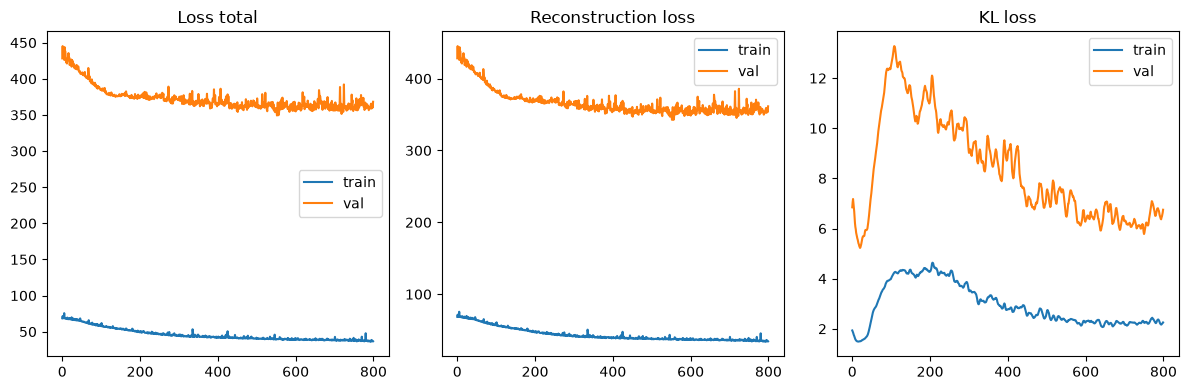

In [16]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss total")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history["recon_loss"], label="train")
plt.plot(history.history["val_recon_loss"], label="val")
plt.title("Reconstruction loss")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history["kl_loss"], label="train")
plt.plot(history.history["val_kl_loss"], label="val")
plt.title("KL loss")
plt.legend()

plt.tight_layout()
plt.show()

## Chequeo de reocnstrucción

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


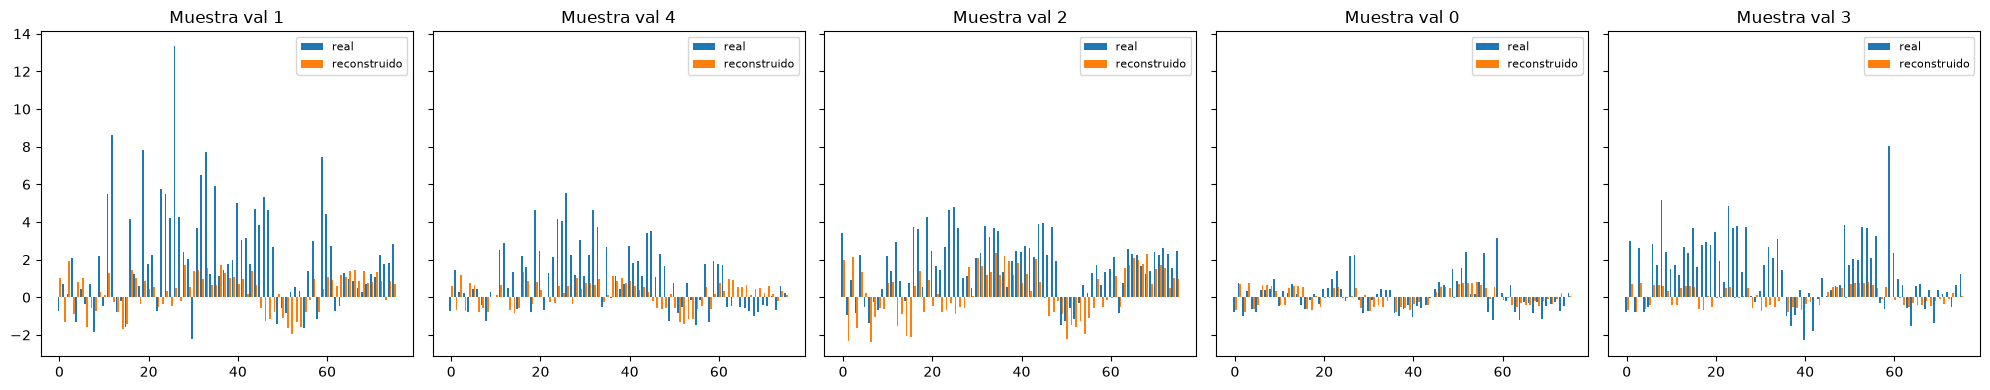

In [17]:
n_muestras = 5
idx_muestra = np.random.choice(len(X_val_s), n_muestras, replace=False)

z_mean_val, z_log_var_val, z_val = encoder.predict([X_val_s, y_val])
reconstruccion_val = decoder.predict([z_val, y_val])

fig, axes = plt.subplots(1, n_muestras, figsize=(4 * n_muestras, 4), sharey=True)
for ax, i in zip(axes, idx_muestra):
    ax.bar(np.arange(input_dim) - 0.2, X_val_s[i], width=0.4, label="real")
    ax.bar(np.arange(input_dim) + 0.2, reconstruccion_val[i], width=0.4, label="reconstruido")
    ax.set_title(f"Muestra val {i}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Espacio latente

Labels de validación: ['infected_viral' 'herbivory_only' 'control' 'infected_viral'
 'herbivory_only']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


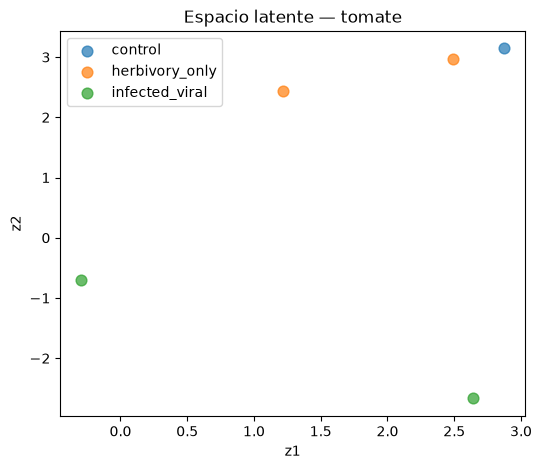

Silhouette score (validación): 0.003763922955840826


In [18]:
from sklearn.metrics import silhouette_score

def dummies_a_label(fila):
    if fila[0] == 1:
        return "herbivory_only"
    elif fila[1] == 1:
        return "infected_viral"
    else:
        return "control"

labels_val = np.array([dummies_a_label(fila) for fila in y_val])
print("Labels de validación:", labels_val)

z_mean_val, _, _ = encoder.predict([X_val_s, y_val])

plt.figure(figsize=(6, 5))
for lbl in ["control", "herbivory_only", "infected_viral"]:
    mask = labels_val == lbl
    plt.scatter(z_mean_val[mask, 0], z_mean_val[mask, 1], label=lbl, alpha=0.7, s=60)

plt.xlabel("z1")
plt.ylabel("z2")
plt.legend()
plt.title("Espacio latente — tomate")
plt.show()

sil = silhouette_score(z_mean_val, labels_val)
print("Silhouette score (validación):", sil)

## Exploraicón de gradiente

In [19]:
z_fixed = np.zeros((1, latent_dim))
n_steps = 11
c_steps = np.linspace(0, 1, n_steps).reshape(-1, 1)
z_repeated = np.repeat(z_fixed, n_steps, axis=0)

# control a herbivory_only
cond_herb = np.hstack([c_steps, np.zeros((n_steps, 1))])
perfiles_herb = decoder.predict([z_repeated, cond_herb])
delta_herb = perfiles_herb[-1] - perfiles_herb[0]

# control a infected_viral
cond_viral = np.hstack([np.zeros((n_steps, 1)), c_steps])
perfiles_viral = decoder.predict([z_repeated, cond_viral])
delta_viral = perfiles_viral[-1] - perfiles_viral[0]

compound_ids = wide.columns

cambios_herb = pd.DataFrame({"compuesto_id": compound_ids, "delta": delta_herb})
cambios_herb = cambios_herb.merge(compuestos[["compuesto_id", "name_original", "pubchem_cid"]], on="compuesto_id", how="left")
cambios_herb = cambios_herb.reindex(cambios_herb["delta"].abs().sort_values(ascending=False).index)

cambios_viral = pd.DataFrame({"compuesto_id": compound_ids, "delta": delta_viral})
cambios_viral = cambios_viral.merge(compuestos[["compuesto_id", "name_original", "pubchem_cid"]], on="compuesto_id", how="left")
cambios_viral = cambios_viral.reindex(cambios_viral["delta"].abs().sort_values(ascending=False).index)

print("Top 1 — control a herbivory_only:")
display(cambios_herb.head(10))

print("\nTop 10 — control a infected_viral:")
display(cambios_viral.head(10))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Top 1 — control a herbivory_only:


,compuesto_id,delta,name_original,pubchem_cid
52,ghosh2022_tomato_cmp053,-0.734003,"1,3-Dimethylbenzene",7929.0
16,ghosh2022_tomato_cmp017,0.596118,Hexanal,23234.0
62,ghosh2022_tomato_cmp063,0.528888,Methyl benzoate,7150.0
2,ghosh2022_tomato_cmp003,0.526491,Ethyl myristate,31283.0
5,ghosh2022_tomato_cmp006,0.519718,"Methyl hexadeca-7,10,13-trienoate",556196.0
47,ghosh2022_tomato_cmp048,-0.506906,alpha-Pinene,6654.0
51,ghosh2022_tomato_cmp052,-0.480171,Guaiacol,460.0
48,ghosh2022_tomato_cmp049,-0.468932,p-Cymene,7463.0
60,ghosh2022_tomato_cmp061,0.458017,3-Ethylbenzaldehyde,118623.0
33,ghosh2022_tomato_cmp034,0.431310,beta-Ionone epoxide,67471.0



Top 10 — control a infected_viral:


,compuesto_id,delta,name_original,pubchem_cid
52,ghosh2022_tomato_cmp053,0.230490,"1,3-Dimethylbenzene",7929.0
16,ghosh2022_tomato_cmp017,-0.205625,Hexanal,23234.0
62,ghosh2022_tomato_cmp063,-0.186819,Methyl benzoate,7150.0
51,ghosh2022_tomato_cmp052,0.165434,Guaiacol,460.0
2,ghosh2022_tomato_cmp003,-0.163613,Ethyl myristate,31283.0
5,ghosh2022_tomato_cmp006,-0.158318,"Methyl hexadeca-7,10,13-trienoate",556196.0
47,ghosh2022_tomato_cmp048,0.148219,alpha-Pinene,6654.0
48,ghosh2022_tomato_cmp049,0.146892,p-Cymene,7463.0
53,ghosh2022_tomato_cmp054,0.145857,"1,2-Dimethoxybenzene",7043.0
60,ghosh2022_tomato_cmp061,-0.142581,3-Ethylbenzaldehyde,118623.0


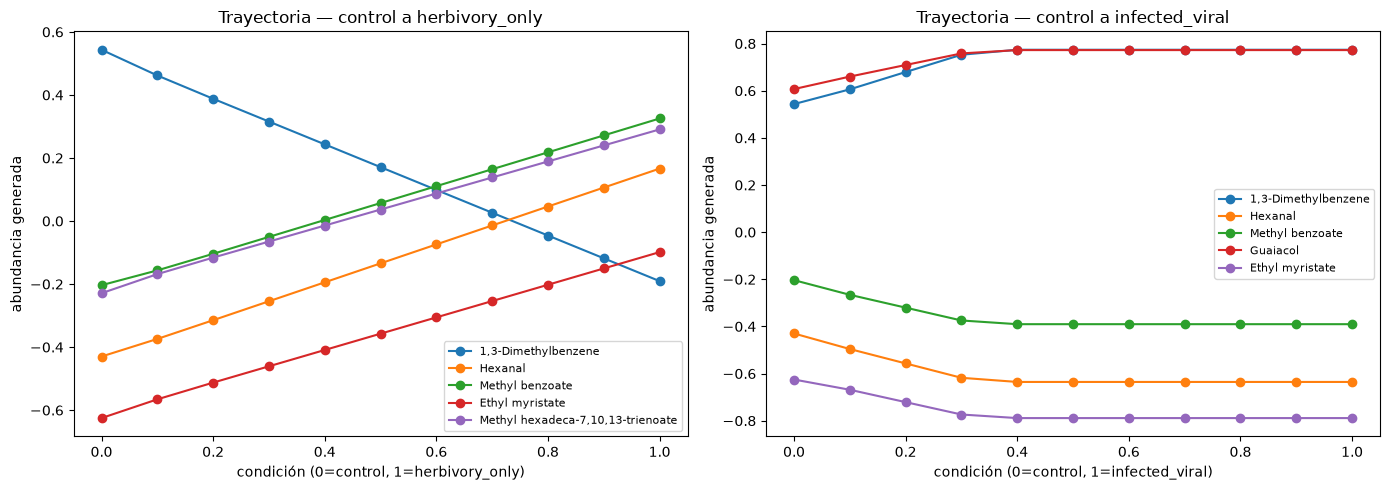

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top5_herb = cambios_herb.head(5)["compuesto_id"].tolist()
idx_top5_herb = [list(compound_ids).index(cid) for cid in top5_herb]

for i, cid in zip(idx_top5_herb, top5_herb):
    nombre = compuestos.loc[compuestos["compuesto_id"] == cid, "name_original"].values
    etiqueta = nombre[0] if len(nombre) else cid
    axes[0].plot(c_steps.flatten(), perfiles_herb[:, i], marker="o", label=etiqueta)

axes[0].set_xlabel("condición (0=control, 1=herbivory_only)")
axes[0].set_ylabel("abundancia generada")
axes[0].legend(fontsize=8)
axes[0].set_title("Trayectoria — control a herbivory_only")

top5_viral = cambios_viral.head(5)["compuesto_id"].tolist()
idx_top5_viral = [list(compound_ids).index(cid) for cid in top5_viral]

for i, cid in zip(idx_top5_viral, top5_viral):
    nombre = compuestos.loc[compuestos["compuesto_id"] == cid, "name_original"].values
    etiqueta = nombre[0] if len(nombre) else cid
    axes[1].plot(c_steps.flatten(), perfiles_viral[:, i], marker="o", label=etiqueta)

axes[1].set_xlabel("condición (0=control, 1=infected_viral)")
axes[1].set_ylabel("abundancia generada")
axes[1].legend(fontsize=8)
axes[1].set_title("Trayectoria — control a infected_viral")

plt.tight_layout()
plt.show()

# Etapa 4

In [21]:
# Isolation forest
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import LeaveOneOut

X_real_ghosh_tomate = np.vstack([X_train_s, X_val_s])
n_real_ghosh_tomate = X_real_ghosh_tomate.shape[0]
print(f"Muestras reales (tomate): {n_real_ghosh_tomate}")

iso_final_ghosh_tomate = IsolationForest(n_estimators=200, contamination="auto", random_state=SEED)
iso_final_ghosh_tomate.fit(X_real_ghosh_tomate)

loo = LeaveOneOut()
scores_loo_ghosh_tomate = np.zeros(n_real_ghosh_tomate)
for train_idx, test_idx in loo.split(X_real_ghosh_tomate):
    iso_fold = IsolationForest(n_estimators=200, contamination="auto", random_state=SEED)
    iso_fold.fit(X_real_ghosh_tomate[train_idx])
    scores_loo_ghosh_tomate[test_idx[0]] = -iso_fold.score_samples(X_real_ghosh_tomate[test_idx])[0]

print("Distribución LOO IF (tomate):")
print(pd.Series(scores_loo_ghosh_tomate).describe())

Muestras reales (tomate): 15
Distribución LOO IF (tomate):
count    15.000000
mean      0.499402
std       0.039402
min       0.452047
25%       0.473264
50%       0.497142
75%       0.511297
max       0.577280
dtype: float64


In [22]:
# % de la distrib de referncia queda debajo de score 
z_extremo_ghosh_tomate = np.full((1, latent_dim), 5.0)
c_extremo_ghosh_tomate = np.array([[1.0, 0.0]])  # herb=1, viral=0
perfil_control_positivo_ghosh_tomate = decoder.predict([z_extremo_ghosh_tomate, c_extremo_ghosh_tomate])

score_if_control_ghosh_tomate = -iso_final_ghosh_tomate.score_samples(perfil_control_positivo_ghosh_tomate)[0]

def percentil_vs_referencia(score, referencia):
    return (referencia < score).mean() * 100

print("Control positivo z=5 (tomte):")
print(f"  IF percentil: {percentil_vs_referencia(score_if_control_ghosh_tomate, scores_loo_ghosh_tomate):.1f}%")

# Control + (dataset muy chico)
rng = np.random.default_rng(0)
perfil_barajado_ghosh_tomate = X_real_ghosh_tomate[0].copy()
rng.shuffle(perfil_barajado_ghosh_tomate)
perfil_barajado_ghosh_tomate = perfil_barajado_ghosh_tomate.reshape(1, -1)

score_baraj_ghosh_tomate = -iso_final_ghosh_tomate.score_samples(perfil_barajado_ghosh_tomate)[0]
print("Perfil barajado (Ghosh tomate):")
print(f"  IF percentil: {percentil_vs_referencia(score_baraj_ghosh_tomate, scores_loo_ghosh_tomate):.1f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Control positivo z=5 (tomte):
  IF percentil: 80.0%
Perfil barajado (Ghosh tomate):
  IF percentil: 0.0%


In [23]:
# Probar IF mas sensible
from sklearn.decomposition import PCA

iso_sensible_tomate = IsolationForest(n_estimators=500, max_features=0.5, contamination="auto", random_state=SEED)
iso_sensible_tomate.fit(X_real_ghosh_tomate)

scores_reales_sensible_tomate = -iso_sensible_tomate.score_samples(X_real_ghosh_tomate)
score_baraj_sensible_tomate = -iso_sensible_tomate.score_samples(perfil_barajado_ghosh_tomate)[0]

print("IF sensible:",
      scores_reales_sensible_tomate.min(), np.median(scores_reales_sensible_tomate), scores_reales_sensible_tomate.max())
print("  Score perfil barajado:", score_baraj_sensible_tomate)

# PCA
pca_tomate = PCA(n_components=3, random_state=SEED)
pca_tomate.fit(X_real_ghosh_tomate)

def error_pca(modelo_pca, X):
    X_proyectado = modelo_pca.transform(X)
    X_reconstruido = modelo_pca.inverse_transform(X_proyectado)
    return np.mean((X - X_reconstruido) ** 2, axis=1)

errores_reales_pca_tomate = error_pca(pca_tomate, X_real_ghosh_tomate)
error_baraj_pca_tomate = error_pca(pca_tomate, perfil_barajado_ghosh_tomate)[0]

print("\nPCA:",
      errores_reales_pca_tomate.min(), np.median(errores_reales_pca_tomate), errores_reales_pca_tomate.max())
print("  Error perfil barajado:", error_baraj_pca_tomate)

IF sensible: 0.42508912785795905 0.48066928202828685 0.5894302114962018
  Score perfil barajado: 0.4574307155376141

PCA: 0.13434109169032055 0.40851029219626567 0.9565001167341891
  Error perfil barajado: 0.5221177791531766


In [24]:
export_cvae(
    "ghosh2022_tomate",
    encoder=encoder, decoder=decoder, scaler=scaler, compound_ids=compound_ids,
    meta={
        "especie": "Solanum lycopersicum (Ghosh 2022)",
        "estado_etapa4": "cualitativo — potencia insuficiente confirmada por control positivo",
    },
)

Exportado: ghosh2022_tomate -> ..\models\ghosh2022_tomate


#  CVAE - Ghosh2022 - Parte pimiento

# Etapa 3

### Carga de datos

In [25]:
SPECIES = "Capsicum annuum"

con = sqlite3.connect(DB_PATH)

muestras_p = pd.read_sql(
    f"SELECT * FROM muestras WHERE dataset_origin = '{DATASET_ORIGIN}' AND species = '{SPECIES}'", con
)
compuestos_all_p = pd.read_sql(
    f"SELECT * FROM compuestos WHERE dataset_origin = '{DATASET_ORIGIN}'", con
)
abundancias_all_p = pd.read_csv(PARQUET_PATH)

con.close()

abundancias_p = abundancias_all_p[abundancias_all_p["sample_id"].isin(muestras_p["sample_id"])]
compuesto_ids_especie_p = abundancias_p["compuesto_id"].unique()
compuestos_p = compuestos_all_p[compuestos_all_p["compuesto_id"].isin(compuesto_ids_especie_p)]

print("Muestras:", muestras_p.shape)
print("Compuestos (pimiento):", compuestos_p.shape)
print("Abundancias:", abundancias_p.shape)
print("\nphysiological_state:")
print(muestras_p["physiological_state"].value_counts())
print("\nNulos en abundancia:", abundancias_p["abundancia"].isna().sum())

muestras_p.head()

Muestras: (14, 19)
Compuestos (pimiento): (93, 15)
Abundancias: (1302, 4)

physiological_state:
physiological_state
control           5
herbivory_only    5
infected_viral    4
Name: count, dtype: int64

Nulos en abundancia: 0


,sample_id,species,genotype,genotype_notes,microorganism,strain,physiological_state,dataset_origin,doi,analytical_technique,timepoint,tissue,experiment_replicate,biological_replicate,load_date,validation_status,intended_use,eje_biologico,metadata_extra
0,ghosh2022_pepper_control_r01,Capsicum annuum,None,None,None,None,control,Ghosh2022,10.3390/insects13090840,HS-SPME-GC-MS,None,leaves,None,1,2026-07-05,pendiente_validacion,classifier,infeccion_viral,"{""virus"": null, ""herbivore_species"": null, ""tr..."
1,ghosh2022_pepper_control_r02,Capsicum annuum,None,None,None,None,control,Ghosh2022,10.3390/insects13090840,HS-SPME-GC-MS,None,leaves,None,2,2026-07-05,pendiente_validacion,classifier,infeccion_viral,"{""virus"": null, ""herbivore_species"": null, ""tr..."
2,ghosh2022_pepper_control_r03,Capsicum annuum,None,None,None,None,control,Ghosh2022,10.3390/insects13090840,HS-SPME-GC-MS,None,leaves,None,3,2026-07-05,pendiente_validacion,classifier,infeccion_viral,"{""virus"": null, ""herbivore_species"": null, ""tr..."
3,ghosh2022_pepper_control_r04,Capsicum annuum,None,None,None,None,control,Ghosh2022,10.3390/insects13090840,HS-SPME-GC-MS,None,leaves,None,4,2026-07-05,pendiente_validacion,classifier,infeccion_viral,"{""virus"": null, ""herbivore_species"": null, ""tr..."
4,ghosh2022_pepper_control_r05,Capsicum annuum,None,None,None,None,control,Ghosh2022,10.3390/insects13090840,HS-SPME-GC-MS,None,leaves,None,5,2026-07-05,pendiente_validacion,classifier,infeccion_viral,"{""virus"": null, ""herbivore_species"": null, ""tr..."


In [26]:
#Chequeo contamientantes
pd.set_option("display.max_rows", None)
compuestos_p[["compuesto_id", "name_original", "cas", "pubchem_cid"]]

,compuesto_id,name_original,cas,pubchem_cid
76,ghosh2022_pepper_cmp001,Pentadecanal,2765-11-9,17697.0
77,ghosh2022_pepper_cmp002,Methyl stearate,112-61-8,8201.0
78,ghosh2022_pepper_cmp003,Dihydroaplotaxene,56134-03-3,92017.0
79,ghosh2022_pepper_cmp004,Methyl pentadecanoate,7132-64-1,23518.0
80,ghosh2022_pepper_cmp005,Methyl palmitate,112-39-0,8181.0
81,ghosh2022_pepper_cmp006,Methyl palmitoleate,1120-25-8,14258.0
82,ghosh2022_pepper_cmp007,cis-Jasmone,488-10-8,10261.0
83,ghosh2022_pepper_cmp008,Phytone,502-69-2,10408.0
84,ghosh2022_pepper_cmp009,Decane,124-18-5,15600.0
85,ghosh2022_pepper_cmp010,"(Z,E)-3,5-Octadien-2-one",4173-41-5,181575.0


### Preprocesamiento

In [27]:
#Pivot
wide_p = abundancias_p.pivot(index="sample_id", columns="compuesto_id", values="abundancia")
print("Nulos en wide_p:", wide_p.isna().sum().sum())
print("Shape wide_p:", wide_p.shape)
wide_p.head()

Nulos en wide_p: 0
Shape wide_p: (14, 93)


compuesto_id,ghosh2022_pepper_cmp001,ghosh2022_pepper_cmp002,ghosh2022_pepper_cmp003,ghosh2022_pepper_cmp004,ghosh2022_pepper_cmp005,ghosh2022_pepper_cmp006,ghosh2022_pepper_cmp007,ghosh2022_pepper_cmp008,ghosh2022_pepper_cmp009,ghosh2022_pepper_cmp010,...,ghosh2022_pepper_cmp084,ghosh2022_pepper_cmp085,ghosh2022_pepper_cmp086,ghosh2022_pepper_cmp087,ghosh2022_pepper_cmp088,ghosh2022_pepper_cmp089,ghosh2022_pepper_cmp090,ghosh2022_pepper_cmp091,ghosh2022_pepper_cmp092,ghosh2022_pepper_cmp093
sample_id,,,,,,,,,,,,,,,,,,,,,
ghosh2022_pepper_control_r01,0.002589,0.002131,0.001448,0.000806,0.000534,0.000810,0.000000,0.000852,0.007405,0.059508,...,0.034709,0.001540,0.003499,0.025749,0.011912,0.799714,0.002671,0.004561,0.005466,0.024070
ghosh2022_pepper_control_r02,0.001783,0.002208,0.001664,0.000880,0.000880,0.001142,0.000000,0.001235,0.010084,0.079363,...,0.044171,0.001475,0.004624,0.030809,0.015893,0.799920,0.003123,0.005460,0.007450,0.026725
ghosh2022_pepper_control_r03,0.006292,0.004918,0.001579,0.002130,0.001687,0.001865,0.000591,0.001969,0.012169,0.073538,...,0.145460,0.005547,0.009163,0.066801,0.022168,0.799906,0.001537,0.008459,0.011542,0.042766
ghosh2022_pepper_control_r04,0.010294,0.005389,0.002115,0.002359,0.001564,0.002185,0.001066,0.001738,0.003717,0.039525,...,0.073703,0.007957,0.002556,0.043515,0.019022,0.800000,0.003476,0.005482,0.008485,0.005906
ghosh2022_pepper_control_r05,0.004501,0.003369,0.001518,0.001425,0.000814,0.001355,0.000261,0.001181,0.001989,0.077161,...,0.070610,0.003990,0.002182,0.047156,0.018542,0.799995,0.003300,0.005816,0.009031,0.033090


In [28]:
#Log1P
X_log_p = np.log1p(wide_p.values)
print("X_log_p shape:", X_log_p.shape)

X_log_p shape: (14, 93)


In [29]:
#Condición + Split
estado_p = muestras_p.set_index("sample_id").loc[wide_p.index, "physiological_state"]

estado_cat_p = pd.Categorical(estado_p, categories=["control", "herbivory_only", "infected_viral"])
cond_dummies_p = pd.get_dummies(estado_cat_p, drop_first=True).astype(float)
print("Columnas de condición:", cond_dummies_p.columns.tolist())
cond_dummies_p.head()

Columnas de condición: ['herbivory_only', 'infected_viral']


,herbivory_only,infected_viral
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0


In [30]:
#División tr/ts
X_train_p, X_val_p, y_train_p, y_val_p = train_test_split(
    X_log_p, cond_dummies_p.values,
    test_size=0.33, stratify=estado_p, random_state=42
)

print("X_train_p:", X_train_p.shape, " X_val_p:", X_val_p.shape)
print("y_train_p:", y_train_p.shape, " y_val_p:", y_val_p.shape)

X_train_p: (9, 93)  X_val_p: (5, 93)
y_train_p: (9, 2)  y_val_p: (5, 2)


In [31]:
# Estandarización
scaler_p = StandardScaler()
X_train_s_p = scaler_p.fit_transform(X_train_p)
X_val_s_p = scaler_p.transform(X_val_p)

print(X_train_s_p.shape, X_val_s_p.shape)

(9, 93) (5, 93)


## Encoder

In [32]:
input_dim_p = X_train_s_p.shape[1]
cond_dim_p = y_train_p.shape[1]
latent_dim = 2

encoder_inputs_p = keras.Input(shape=(input_dim_p,), name="x_input_p")
encoder_cond_p = keras.Input(shape=(cond_dim_p,), name="cond_input_p")
x = layers.concatenate([encoder_inputs_p, encoder_cond_p])
x = layers.Dense(4, activation="relu")(x)
z_mean_p = layers.Dense(latent_dim, name="z_mean_p")(x)
z_log_var_p = layers.Dense(latent_dim, name="z_log_var_p")(x)
z_p = layers.Lambda(sampling, name="z_p")([z_mean_p, z_log_var_p])

encoder_p = keras.Model([encoder_inputs_p, encoder_cond_p], [z_mean_p, z_log_var_p, z_p], name="encoder_p")
encoder_p.summary()

Model: "encoder_p"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ x_input_p (InputLayer)        │ (None, 93)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cond_input_p (InputLayer)     │ (None, 2)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_2 (Concatenate)   │ (None, 95)                │               0 │ x_input_p[0][0],           │
│                               │                           │                 │ cond_input_p[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 4)                 │             384 │ concatenate_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_mean_p (Dense)              │ (None, 2)                 │              10 │ dense_3[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_log_var_p (Dense)           │ (None, 2)                 │              10 │ dense_3[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_p (Lambda)                  │ (None, 2)                 │               0 │ z_mean_p[0][0],            │
│                               │                           │                 │ z_log_var_p[0][0]          │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 404 (1.58 KB)

 Trainable params: 404 (1.58 KB)

 Non-trainable params: 0 (0.00 B)

## Decoder

In [33]:
latent_inputs_p = keras.Input(shape=(latent_dim,), name="z_input_p")
decoder_cond_p = keras.Input(shape=(cond_dim_p,), name="cond_input_dec_p")
x = layers.concatenate([latent_inputs_p, decoder_cond_p])
x = layers.Dense(4, activation="relu")(x)
decoder_outputs_p = layers.Dense(input_dim_p, activation="linear")(x)

decoder_p = keras.Model([latent_inputs_p, decoder_cond_p], decoder_outputs_p, name="decoder_p")
decoder_p.summary()

Model: "decoder_p"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ z_input_p (InputLayer)        │ (None, 2)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ cond_input_dec_p (InputLayer) │ (None, 2)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_3 (Concatenate)   │ (None, 4)                 │               0 │ z_input_p[0][0],           │
│                               │                           │                 │ cond_input_dec_p[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 4)                 │              20 │ concatenate_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 93)                │             465 │ dense_4[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 485 (1.89 KB)

 Trainable params: 485 (1.89 KB)

 Non-trainable params: 0 (0.00 B)

## CVAE completo

In [34]:
class CVAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")
        self.beta = tf.Variable(1.0, trainable=False, dtype=tf.float32)

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def _compute_losses(self, x, cond):
        z_mean, z_log_var, z = self.encoder([x, cond])
        reconstruction = self.decoder([z, cond])
        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(x - reconstruction), axis=1))
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        total_loss = recon_loss + self.beta * kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        x, cond = data
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self._compute_losses(x, cond)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, cond = data
        total_loss, recon_loss, kl_loss = self._compute_losses(x, cond)
        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

## Entrenamiento

In [35]:
class KLWarmup(keras.callbacks.Callback):
    def __init__(self, total_epochs):
        super().__init__()
        self.total_epochs = total_epochs

    def on_epoch_begin(self, epoch, logs=None):
        new_beta = min(1.0, epoch / (self.total_epochs * 0.5))
        self.model.beta.assign(new_beta)

cvae_p = CVAE(encoder_p, decoder_p)
cvae_p.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

EPOCHS = 800
BATCH_SIZE = 4  # solo 9 muestras de train

history_p = cvae_p.fit(
    X_train_s_p, y_train_p,
    validation_data=(X_val_s_p, y_val_p),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[KLWarmup(EPOCHS)],
    verbose=0,
)

n_ultimas = 50
print("Promedio últimas", n_ultimas, "épocas:")
print("recon_loss (train):", np.mean(history_p.history["recon_loss"][-n_ultimas:]))
print("recon_loss (val):", np.mean(history_p.history["val_recon_loss"][-n_ultimas:]))
print("kl_loss (train):", np.mean(history_p.history["kl_loss"][-n_ultimas:]))
print("kl_loss (val):", np.mean(history_p.history["val_kl_loss"][-n_ultimas:]))

Promedio últimas 50 épocas:
recon_loss (train): 24.437133293151856
recon_loss (val): 339.8220471191406
kl_loss (train): 3.0936057472229006
kl_loss (val): 25.474768104553224


## Curva de pérdida

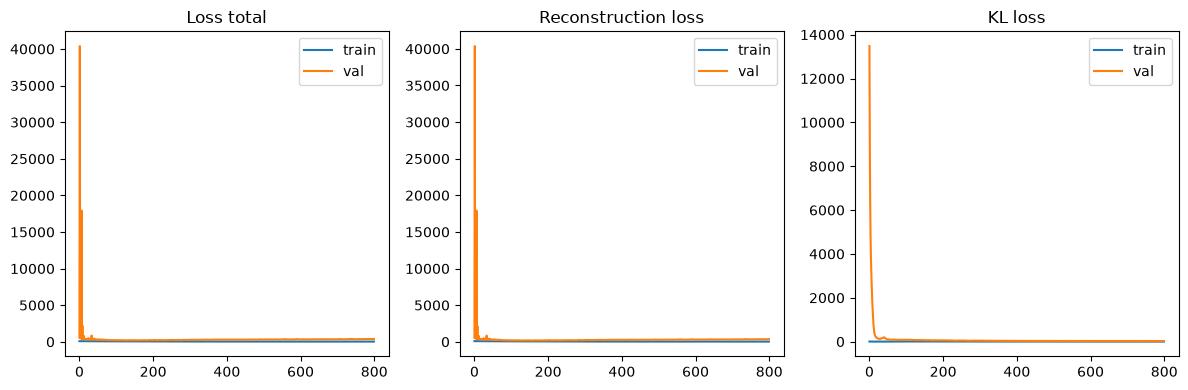

In [36]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(history_p.history["loss"], label="train")
plt.plot(history_p.history["val_loss"], label="val")
plt.title("Loss total")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history_p.history["recon_loss"], label="train")
plt.plot(history_p.history["val_recon_loss"], label="val")
plt.title("Reconstruction loss")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history_p.history["kl_loss"], label="train")
plt.plot(history_p.history["val_kl_loss"], label="val")
plt.title("KL loss")
plt.legend()

plt.tight_layout()
plt.show()

## Chequeo de reconstrucción

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


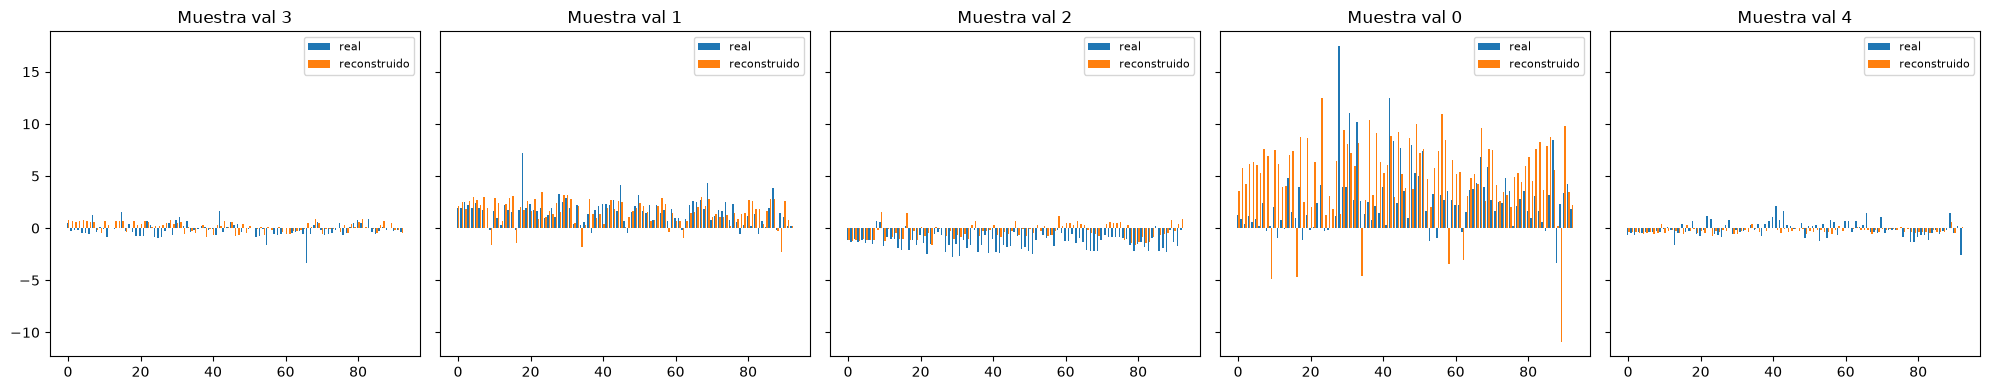

In [37]:
n_muestras = 5
idx_muestra = np.random.choice(len(X_val_s_p), n_muestras, replace=False)

z_mean_val_p, z_log_var_val_p, z_val_p = encoder_p.predict([X_val_s_p, y_val_p])
reconstruccion_val_p = decoder_p.predict([z_val_p, y_val_p])

fig, axes = plt.subplots(1, n_muestras, figsize=(4 * n_muestras, 4), sharey=True)
for ax, i in zip(axes, idx_muestra):
    ax.bar(np.arange(input_dim_p) - 0.2, X_val_s_p[i], width=0.4, label="real")
    ax.bar(np.arange(input_dim_p) + 0.2, reconstruccion_val_p[i], width=0.4, label="reconstruido")
    ax.set_title(f"Muestra val {i}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Espacio latente

Labels de validación: ['infected_viral' 'herbivory_only' 'control' 'herbivory_only' 'control']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


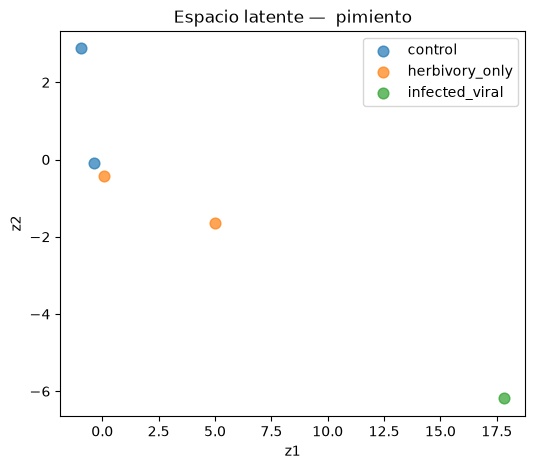

Silhouette score (validación): 0.017438754439353943


In [38]:
from sklearn.metrics import silhouette_score

def dummies_a_label(fila):
    if fila[0] == 1:
        return "herbivory_only"
    elif fila[1] == 1:
        return "infected_viral"
    else:
        return "control"

labels_val_p = np.array([dummies_a_label(fila) for fila in y_val_p])
print("Labels de validación:", labels_val_p)

z_mean_val_p, _, _ = encoder_p.predict([X_val_s_p, y_val_p])

plt.figure(figsize=(6, 5))
for lbl in ["control", "herbivory_only", "infected_viral"]:
    mask = labels_val_p == lbl
    plt.scatter(z_mean_val_p[mask, 0], z_mean_val_p[mask, 1], label=lbl, alpha=0.7, s=60)

plt.xlabel("z1")
plt.ylabel("z2")
plt.legend()
plt.title("Espacio latente —  pimiento")
plt.show()

sil = silhouette_score(z_mean_val_p, labels_val_p)
print("Silhouette score (validación):", sil)

## Exploración del gradiente

In [39]:
z_fixed = np.zeros((1, latent_dim))
n_steps = 11
c_steps = np.linspace(0, 1, n_steps).reshape(-1, 1)
z_repeated = np.repeat(z_fixed, n_steps, axis=0)

cond_herb_p = np.hstack([c_steps, np.zeros((n_steps, 1))])
perfiles_herb_p = decoder_p.predict([z_repeated, cond_herb_p])
delta_herb_p = perfiles_herb_p[-1] - perfiles_herb_p[0]

cond_viral_p = np.hstack([np.zeros((n_steps, 1)), c_steps])
perfiles_viral_p = decoder_p.predict([z_repeated, cond_viral_p])
delta_viral_p = perfiles_viral_p[-1] - perfiles_viral_p[0]

compound_ids_p = wide_p.columns

cambios_herb_p = pd.DataFrame({"compuesto_id": compound_ids_p, "delta": delta_herb_p})
cambios_herb_p = cambios_herb_p.merge(compuestos_p[["compuesto_id", "name_original", "pubchem_cid"]], on="compuesto_id", how="left")
cambios_herb_p = cambios_herb_p.reindex(cambios_herb_p["delta"].abs().sort_values(ascending=False).index)

cambios_viral_p = pd.DataFrame({"compuesto_id": compound_ids_p, "delta": delta_viral_p})
cambios_viral_p = cambios_viral_p.merge(compuestos_p[["compuesto_id", "name_original", "pubchem_cid"]], on="compuesto_id", how="left")
cambios_viral_p = cambios_viral_p.reindex(cambios_viral_p["delta"].abs().sort_values(ascending=False).index)

print("Top 10 — control a herbivory_only:")
display(cambios_herb_p.head(10))

print("\nTop 10 — control a infected_viral:")
display(cambios_viral_p.head(10))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Top 10 — control a herbivory_only:


,compuesto_id,delta,name_original,pubchem_cid
4,ghosh2022_pepper_cmp005,1.291787,Methyl palmitate,8181.0
81,ghosh2022_pepper_cmp082,1.264787,Phenylacealdehyde,998.0
15,ghosh2022_pepper_cmp016,1.214098,Methyl laurate,8139.0
5,ghosh2022_pepper_cmp006,1.194933,Methyl palmitoleate,14258.0
87,ghosh2022_pepper_cmp088,1.194645,3-Ethylbenzaldehyde,118623.0
7,ghosh2022_pepper_cmp008,1.184016,Phytone,10408.0
0,ghosh2022_pepper_cmp001,1.123794,Pentadecanal,17697.0
14,ghosh2022_pepper_cmp015,1.116262,"Nonanoic acid, 9-oxo-, methyl ester",74732.0
21,ghosh2022_pepper_cmp022,1.100621,Methyl hexadec-9-enoate,14258.0
68,ghosh2022_pepper_cmp069,1.097301,2-Pentylfuran,19602.0



Top 10 — control a infected_viral:


,compuesto_id,delta,name_original,pubchem_cid
79,ghosh2022_pepper_cmp080,1.014060,Methyl salicylate,4133.0
58,ghosh2022_pepper_cmp059,-1.010865,trans-3-Nonen-2-one,26630.0
72,ghosh2022_pepper_cmp073,-0.958353,beta-Cyclocitral,9895.0
78,ghosh2022_pepper_cmp079,0.933922,Guaiacol,460.0
16,ghosh2022_pepper_cmp017,-0.919611,"3,5-Octadien-2-one",181575.0
84,ghosh2022_pepper_cmp085,0.907739,Benzeneethanol,6054.0
73,ghosh2022_pepper_cmp074,-0.895606,beta-Ionone,26955.0
74,ghosh2022_pepper_cmp075,-0.847775,beta-Ionone epoxide,67471.0
82,ghosh2022_pepper_cmp083,0.833268,Methyl benzoate,7150.0
83,ghosh2022_pepper_cmp084,0.809517,"1,2-Dimethoxybenzene",7043.0


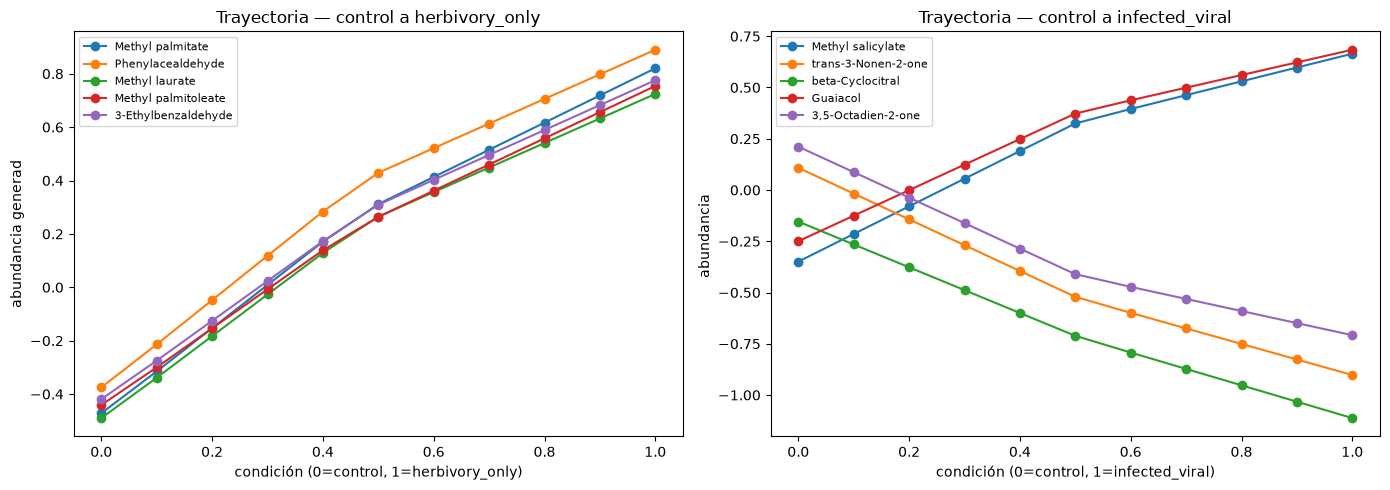

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top5_herb_p = cambios_herb_p.head(5)["compuesto_id"].tolist()
idx_top5_herb_p = [list(compound_ids_p).index(cid) for cid in top5_herb_p]

for i, cid in zip(idx_top5_herb_p, top5_herb_p):
    nombre = compuestos_p.loc[compuestos_p["compuesto_id"] == cid, "name_original"].values
    etiqueta = nombre[0] if len(nombre) else cid
    axes[0].plot(c_steps.flatten(), perfiles_herb_p[:, i], marker="o", label=etiqueta)

axes[0].set_xlabel("condición (0=control, 1=herbivory_only)")
axes[0].set_ylabel("abundancia generad")
axes[0].legend(fontsize=8)
axes[0].set_title("Trayectoria — control a herbivory_only")

top5_viral_p = cambios_viral_p.head(5)["compuesto_id"].tolist()
idx_top5_viral_p = [list(compound_ids_p).index(cid) for cid in top5_viral_p]

for i, cid in zip(idx_top5_viral_p, top5_viral_p):
    nombre = compuestos_p.loc[compuestos_p["compuesto_id"] == cid, "name_original"].values
    etiqueta = nombre[0] if len(nombre) else cid
    axes[1].plot(c_steps.flatten(), perfiles_viral_p[:, i], marker="o", label=etiqueta)

axes[1].set_xlabel("condición (0=control, 1=infected_viral)")
axes[1].set_ylabel("abundancia ")
axes[1].legend(fontsize=8)
axes[1].set_title("Trayectoria — control a infected_viral")

plt.tight_layout()
plt.show()

# Etapa 4

In [41]:
# Isolation forest
from sklearn.model_selection import LeaveOneOut

X_real_ghosh_pimiento = np.vstack([X_train_s_p, X_val_s_p])
n_real_ghosh_pimiento = X_real_ghosh_pimiento.shape[0]
print(f"Muestras reales ( pimiento): {n_real_ghosh_pimiento}")

iso_final_ghosh_pimiento = IsolationForest(n_estimators=200, contamination="auto", random_state=SEED)
iso_final_ghosh_pimiento.fit(X_real_ghosh_pimiento)

loo = LeaveOneOut()
scores_loo_ghosh_pimiento = np.zeros(n_real_ghosh_pimiento)
for train_idx, test_idx in loo.split(X_real_ghosh_pimiento):
    iso_fold = IsolationForest(n_estimators=200, contamination="auto", random_state=SEED)
    iso_fold.fit(X_real_ghosh_pimiento[train_idx])
    scores_loo_ghosh_pimiento[test_idx[0]] = -iso_fold.score_samples(X_real_ghosh_pimiento[test_idx])[0]

print("Distribución LOO IF (pimiento):")
print(pd.Series(scores_loo_ghosh_pimiento).describe())

Muestras reales ( pimiento): 14
Distribución LOO IF (pimiento):
count    14.000000
mean      0.488015
std       0.047242
min       0.426398
25%       0.448695
50%       0.484761
75%       0.511598
max       0.589117
dtype: float64


In [42]:
# Control positivo
rng = np.random.default_rng(0)
perfil_barajado_ghosh_pimiento = X_real_ghosh_pimiento[0].copy()
rng.shuffle(perfil_barajado_ghosh_pimiento)
perfil_barajado_ghosh_pimiento = perfil_barajado_ghosh_pimiento.reshape(1, -1)

score_baraj_ghosh_pimiento = -iso_final_ghosh_pimiento.score_samples(perfil_barajado_ghosh_pimiento)[0]
print("Perfil barajado (pimiento):")
print(f"  IF percentil: {percentil_vs_referencia(score_baraj_ghosh_pimiento, scores_loo_ghosh_pimiento):.1f}%")

# ajuste con max_features reducido
iso_sensible_pimiento = IsolationForest(n_estimators=500, max_features=0.5, contamination="auto", random_state=SEED)
iso_sensible_pimiento.fit(X_real_ghosh_pimiento)
scores_reales_sensible_pimiento = -iso_sensible_pimiento.score_samples(X_real_ghosh_pimiento)
score_baraj_sensible_pimiento = -iso_sensible_pimiento.score_samples(perfil_barajado_ghosh_pimiento)[0]

print("\nIF sensible :",
      scores_reales_sensible_pimiento.min(), np.median(scores_reales_sensible_pimiento), scores_reales_sensible_pimiento.max())
print("  Score perfil barajado:", score_baraj_sensible_pimiento)

Perfil barajado (pimiento):
  IF percentil: 57.1%

IF sensible : 0.42496974059672454 0.4680654763045894 0.642183074049787
  Score perfil barajado: 0.4988009008595491


In [43]:
export_cvae(
    "ghosh2022_pimiento",
    encoder=encoder_p, decoder=decoder_p, scaler=scaler_p, compound_ids=compound_ids_p,
    meta={
        "especie": "Capsicum annuum (Ghosh 2022)",
        "estado_etapa4": "cualitativo — potencia insuficiente confirmada por control positivo",
    },
)

Exportado: ghosh2022_pimiento -> ..\models\ghosh2022_pimiento
